# Environment Setup

## Load Models

In [ ]:
from xgboost import XGBClassifier
import json
import joblib

In [ ]:
# xgboost model
model_gxb = XGBClassifier()
model_gxb.load_model("model/xgb_v2_model.json")
with open("model/xgb_v2_meta.json", "r", encoding="utf-8") as f:
    meta_gxb = json.load(f)

# logistic regression model
model_logreg = joblib.load("model/logreg_model.joblib")
with open("model/logreg_meta.json", "r", encoding="utf-8") as f:
    meta_logreg = json.load(f)

# random forest model
model_rf = joblib.load("model/rf_model.joblib")
with open("model/rf_meta.json", "r", encoding="utf-8") as f:
    meta_rf = json.load(f)

## Load Data

In [ ]:
import pandas as pd
df_test = pd.read_csv("https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/test.csv")
df_train = pd.read_csv("https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/train.csv")

X_test = df_test.drop(columns=["y"])
X_test = X_test[meta_rf["feature_names"]]
y_test = df_test["y"]

X_train = df_train.drop(columns=["y"])
X_train = X_train[meta_rf["feature_names"]]
y_train = df_train["y"]

In [ ]:
from sklearn.model_selection import train_test_split
df_raw = pd.read_csv('data/bank-additional-full.csv', sep=';')
df_train_raw, df_test_raw = train_test_split(df_raw, test_size=0.2, random_state=42)

## Quick Model Check

In [ ]:
from sklearn.metrics import classification_report

y_pred_rf = model_rf.predict(X_test)
print("========== Random Forest Model ==========")
print(classification_report(y_test, y_pred_rf))
print()

y_pred_lr = model_logreg.predict(X_test)
print("========== Logistic Regression Model ==========")
print(classification_report(y_test, y_pred_lr))
print()

y_pred_gxb = model_gxb.predict(X_test)
print("========== XGBoost Model ==========")
print(classification_report(y_test, y_pred_gxb))

========== Random Forest Model ==========
              precision    recall  f1-score   support

       False       0.94      0.93      0.93      7310
        True       0.49      0.56      0.53       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.89      0.89      8238


========== Logistic Regression Model ==========
              precision    recall  f1-score   support

       False       0.91      0.99      0.95      7310
        True       0.68      0.18      0.29       928

    accuracy                           0.90      8238
   macro avg       0.79      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238


========== XGBoost Model ==========
              precision    recall  f1-score   support

       False       0.95      0.91      0.93      7310
        True       0.46      0.62      0.53       928

    accuracy                           0.88      8238


# Survial Analysis

- fit Cox Proportional Hazards Model
- plot survival curves for different groups (e.g., by age, job, etc.)
- interpret the results to understand which factors are associated with higher or lower survival probabilities
- check with the assumptions of the Cox model

# Macroeconomics Sensitivity Analysis

- analyze how changes in macroeconomic indicators (e.g., interest rates, unemployment rates) affect the model's predictions
- perform sensitivity analysis by varying these indicators and observing the impact on the predicted probabilities of subscription

In [ ]:
# sample datapoints for analysis
n_samples = 10
sample_raw = df_test_raw.sample(n=n_samples, random_state=42)
sample_raw.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
7892,45,management,married,university.degree,no,no,no,telephone,jun,mon,...,2,999,0,nonexistent,1.4,94.465,-41.8,4.865,5228.1,no
24925,40,technician,married,professional.course,no,yes,no,cellular,nov,tue,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
36896,31,technician,single,university.degree,no,yes,yes,cellular,jun,fri,...,5,999,0,nonexistent,-2.9,92.963,-40.8,1.224,5076.2,no
1086,53,retired,married,basic.4y,unknown,yes,no,telephone,may,wed,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.856,5191.0,no
21780,58,blue-collar,married,basic.9y,unknown,yes,no,cellular,aug,wed,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no


In [ ]:
import numpy as np
from lib import *

# set range of macroeconomic indicators for analysis
n_ranges = 100
macroeconomic_indicators = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
ranges = {x: np.linspace(df_raw[x].min(), df_raw[x].max(), n_ranges) for x in macroeconomic_indicators}

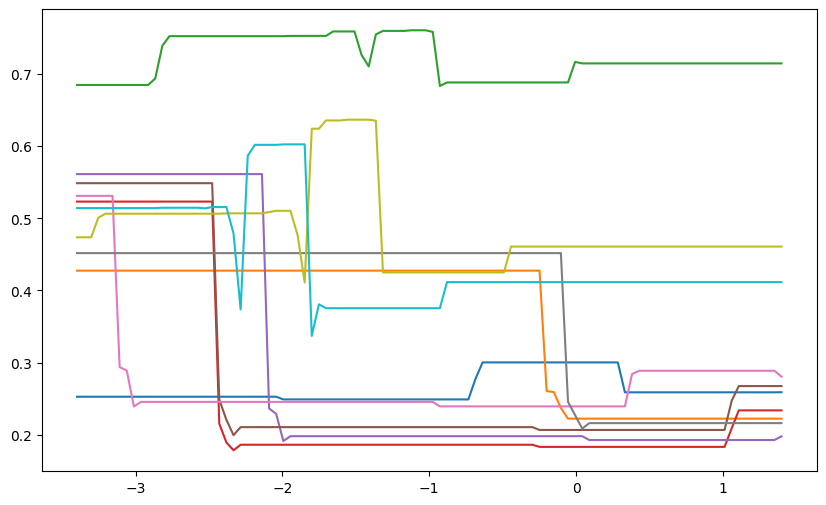

In [ ]:
# analyze model predictions across macroeconomic indicator ranges
import matplotlib.pyplot as plt
for indicator in macroeconomic_indicators[:1]:
    plot = plt.figure(figsize=(10, 6))

    for i in range(n_samples):
        sample = sample_raw.iloc[i]
        sample_repeated = pd.DataFrame([sample] * n_ranges, columns=sample_raw.columns)
        sample_repeated[indicator] = ranges[indicator]
        sample_repeated = tp_prime(sample_repeated)
        sample_repeated = sample_repeated[meta_rf["feature_names"]]

        pred_proba_xgb = model_gxb.predict_proba(sample_repeated)[:, 1]
        # plot data
        plt.plot(ranges[indicator], pred_proba_xgb, label=f"Sample {i+1}")